# Local EDA 

**Work outline**
- Review resampled 10 min vs. aligned 10 min resample

In [161]:
#Import relevant libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis, ks_2samp

import warnings
warnings.filterwarnings('ignore')

#Display settings 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)

#Plot settings
sns.set_theme(
    style="darkgrid",
    context="notebook",
    font_scale=1.1
)

plt.rcParams['figure.dpi'] = 100  # Higher resolution figures
plt.rcParams['savefig.dpi'] = 300  # High quality when saving
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 13

In [ ]:
#Upload csv files 

#10-min resampled
df_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_10T.csv", index_col=0, parse_dates=True)

#10-min resampled (aligned)
df_aligned_10T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_aligned_10T.csv", index_col=0, parse_dates=True)

#Upload orginal csv file for comparison
df_t1 = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_t1_cleaned.csv", index_col=0, parse_dates=True)

In [71]:
#Upload 2-min resampled dataframe for comparison
df_2T = pd.read_csv("~/Desktop/Coding/cive70088/EDS_Design_Project/data/EDA/df_2T.csv", index_col=0, parse_dates=True)

In [72]:
#Check index type
print("Index type of df_10T:", type(df_10T.index))
print("Index type of df_aligned_10T:", type(df_aligned_10T.index))
print("Index type of df_t1:", type(df_t1.index))
print("Index type of df_2T:", type(df_2T.index))

Index type of df_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_aligned_10T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_t1: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index type of df_2T: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [73]:
#Ensure chronological order of dataframes
df_10T.sort_index(inplace=True)
df_aligned_10T.sort_index(inplace=True)
df_t1.sort_index(inplace=True)
df_2T.sort_index(inplace=True)

In [74]:
#Check shape of dataframes
print("Shape of df_10T:", df_10T.shape)
print("Shape of df_aligned_10T:", df_aligned_10T.shape)
print("Shape of df_t1 (original sampling frequency):", df_t1.shape)
print("Shape of df_2T:", df_2T.shape)

Shape of df_10T: (105264, 34)
Shape of df_aligned_10T: (105264, 34)
Shape of df_t1 (original sampling frequency): (798466, 34)
Shape of df_2T: (526320, 34)


In [76]:
#Check time range of dataframes to ensure they cover the same period
print("Time range of df_10T:", df_10T.index.min(), "to", df_10T.index.max())
print("Time range of df_aligned_10T:", df_aligned_10T.index.min(), "to", df_aligned_10T.index.max())
print("Time range of df_t1:", df_t1.index.min(), "to", df_t1.index.max())
print("Time range of df_2T:", df_2T.index.min(), "to", df_2T.index.max())

Time range of df_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_aligned_10T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:50:00+00:00
Time range of df_t1: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00
Time range of df_2T: 2022-06-11 22:00:00+00:00 to 2024-06-11 21:58:00+00:00


OK - the time range of the raw dataset is Time range: 2022-06-11 22:01:00+00:00 to 2024-06-11 21:59:00+00:00. 

In [36]:
print("10-min resampled dataset:")
display(df_10T.head(5))
print()
print("10-min resampled (aligned) dataset:")
display(df_aligned_10T.head(5))
print()
print("Original dataset:")
display(df_t1.head(5))


10-min resampled dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,NaN,0.353097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



10-min resampled (aligned) dataset:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.103247,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.141629,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.324748,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.266913,NaN,1.481867,NaN,0.353097,NaN,2.0,2121.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.306728,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0



Original dataset:


,total_airflow,total_airflow_q,t1_valve_pct,t1_valve_pct_q,t1_n2o,t1_n2o_q,t1_nh4,t1_nh4_q,t1_no3,t1_no3_q,t1_do,t1_do_q,t1_do_sp,t1_do_sp_q,t1_phase,t1_phase_q,t1_airflow,t1_airflow_q,t1_ss,t1_ss_q,t1_temp,t1_temp_q,phasecode,phasecode_q,inlet_tank,inlet_tank_q,outlet_tank,outlet_tank_q,t1_po4,t1_po4_q,inflow,inflow_q,storm_mode,storm_mode_q
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:01:00+00:00,26829.375000,1.0,NaN,NaN,0.723958,0.0,1.670585,0.0,0.413642,0.0,0.094763,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.525374,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.285834,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:02:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.238239,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:03:00+00:00,29626.341797,1.0,NaN,NaN,0.721644,0.0,1.531775,0.0,0.413642,0.0,0.115741,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.536805,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN
2022-06-11 22:04:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.154271,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1222.0,0.0,1.0,0.0,2.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0
2022-06-11 22:05:00+00:00,28605.208984,1.0,NaN,NaN,0.680556,0.0,1.440835,0.0,0.395636,0.0,0.366030,0.0,NaN,NaN,2.0,0.0,NaN,NaN,1.509847,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273499,1.0,NaN,NaN,NaN,NaN


## Statistical Analysis of Resampled Data Frames 

Compare 10 min resampled dataframes (timestamps aligned and not aligned) to the original dataframe

In [38]:
#Before comparing the two datasets, check that time indices are equal
df_10T.index.equals(df_aligned_10T.index)

True

In [39]:
#Define diagnostic function to check timestamp alignment between two dataframes

def check_timestamp_alignment(df1, df2, name1="DF1", name2="DF2"):
    
    idx1 = df1.index
    idx2 = df2.index

    print(f"{name1} rows: {len(idx1)}")
    print(f"{name2} rows: {len(idx2)}")

    if idx1.equals(idx2):
        print("✔ Indexes are identical.")
        return True

    print("✘ Indexes are NOT identical.\n")

    only_in_df1 = idx1.difference(idx2)
    only_in_df2 = idx2.difference(idx1)

    print(f"Timestamps only in {name1}: {len(only_in_df1)}")
    print(f"Timestamps only in {name2}: {len(only_in_df2)}")

    if len(only_in_df1) > 0:
        print(f"Example from {name1} only:", only_in_df1[:5])

    if len(only_in_df2) > 0:
        print(f"Example from {name2} only:", only_in_df2[:5])

    return False

In [40]:
check_timestamp_alignment(
    df_10T,
    df_aligned_10T,
    name1="Standard 10T",
    name2="Aligned 10T"
)

Standard 10T rows: 105264
Aligned 10T rows: 105264
✔ Indexes are identical.


True

In [50]:
#Define key features for analysis to compare the two resampled data frames
cols_analysis = ['inflow', 't1_airflow', 't1_n2o', 't1_nh4','t1_no3', 't1_do', 't1_temp', 't1_po4',
             't1_ss', 't1_valve_pct']

In [42]:
def compare_two_datasets_table(df1, df2, cols=None, name1="DF1", name2="DF2"):

    # Detect shared numeric columns if not specified
    if cols is None:
        num1 = df1.select_dtypes(include="number").columns
        num2 = df2.select_dtypes(include="number").columns
        cols = list(set(num1).intersection(num2))

    results = []

    for col in cols:

        s1 = df1[col].dropna()
        s2 = df2[col].dropna()

        if len(s1) == 0 or len(s2) == 0:
            continue

        mean1, mean2 = s1.mean(), s2.mean()
        std1, std2 = s1.std(), s2.std()

        ks_stat, ks_p = ks_2samp(s1, s2)

        results.append({
            "variable": col,

            f"rows_{name1}": len(df1),
            f"rows_{name2}": len(df2),

            f"mean_{name1}": mean1,
            f"mean_{name2}": mean2,
            "mean_diff": mean2 - mean1,

            f"std_{name1}": std1,
            f"std_{name2}": std2,
            "std_ratio": std2 / std1 if std1 != 0 else np.nan,

            f"median_{name1}": s1.median(),
            f"median_{name2}": s2.median(),

            f"IQR_{name1}": s1.quantile(0.75) - s1.quantile(0.25),
            f"IQR_{name2}": s2.quantile(0.75) - s2.quantile(0.25),

            f"skew_{name1}": skew(s1),
            f"skew_{name2}": skew(s2),

            f"kurtosis_{name1}": kurtosis(s1),
            f"kurtosis_{name2}": kurtosis(s2),

            f"missing_%_{name1}": df1[col].isna().mean() * 100,
            f"missing_%_{name2}": df2[col].isna().mean() * 100,

            "KS_statistic": ks_stat,
            "KS_p_value": ks_p
        })

    return pd.DataFrame(results).sort_values("variable")

In [ ]:
comparison = compare_two_datasets_table(
    df_10T,
    df_aligned_10T,
    cols_analysis,
    name1="10T",
    name2="aligned"
)

comparison

,variable,rows_10T,rows_aligned,mean_10T,mean_aligned,mean_diff,std_10T,std_aligned,std_ratio,median_10T,median_aligned,IQR_10T,IQR_aligned,skew_10T,skew_aligned,kurtosis_10T,kurtosis_aligned,missing_%_10T,missing_%_aligned,KS_statistic,KS_p_value
0,inflow,105264,105264,3083.477209,3083.172523,-0.304686,2187.110523,2188.031254,1.000421,2319.155070,2319.097217,2043.402734,2037.644755,1.462880,1.462291,2.230519,2.229822,13.633341,13.635241,0.002905,0.836430
1,t1_airflow,105264,105264,2187.268389,2187.190458,-0.077931,2020.493134,2020.201553,0.999856,2190.054934,2187.724329,3938.204852,3936.867152,0.277609,0.277741,-1.331575,-1.330921,10.163969,10.161119,0.001273,0.999999
5,t1_do,105264,105264,0.653175,0.653207,0.000032,0.569061,0.569319,1.000454,0.437970,0.437862,0.846336,0.846336,1.627498,1.633424,11.695298,11.750148,1.407889,1.414539,0.001226,0.999999
2,t1_n2o,105264,105264,0.128340,0.128367,0.000027,0.225140,0.225162,1.000096,0.037731,0.037616,0.121296,0.121412,3.479031,3.477501,16.170144,16.155377,2.664729,2.690378,0.000746,1.000000
3,t1_nh4,105264,105264,2.311437,2.311440,0.000003,2.200410,2.200323,0.999961,1.869051,1.870586,2.057673,2.061961,4.147375,4.148012,27.896563,27.905162,1.022192,1.024092,0.000791,1.000000
4,t1_no3,105264,105264,3.116311,3.116332,0.000021,2.771673,2.772084,1.000148,2.511774,2.511954,2.535694,2.538509,6.460901,6.459194,78.816717,78.787417,1.020292,1.021242,0.001298,0.999993
7,t1_po4,105264,105264,1.124365,1.124290,-0.000075,0.957438,0.957453,1.000016,0.891840,0.891922,0.927564,0.927804,3.295983,3.298196,20.948145,20.968501,1.069691,1.072541,0.000816,1.000000
8,t1_ss,105264,105264,2.552777,2.552733,-0.000044,0.852093,0.852148,1.000064,2.548741,2.548539,0.823943,0.824772,-0.223153,-0.223000,1.280149,1.278433,1.020292,1.023142,0.000877,1.000000
6,t1_temp,105264,105264,15.660482,15.660668,0.000186,3.381279,3.381365,1.000025,15.635127,15.635648,6.283004,6.283185,-0.001703,-0.001573,-1.335390,-1.334604,3.699270,3.701170,0.000160,1.000000
9,t1_valve_pct,105264,105264,44.470745,44.468659,-0.002086,40.266240,40.268408,1.000054,43.500000,43.560001,85.740001,85.779999,0.099639,0.099971,-1.677241,-1.677429,4.411765,4.419365,0.000949,1.000000


In [48]:
print(df_t1.index.min(), df_t1.index.max())
print(df_10T.index.min(), df_10T.index.max())

#Trim df_t1 to match the time range of the resampled datasets for a fair comparison
df_t1_trimmed = df_t1.loc[df_10T.index.min():df_10T.index.max()]

print(df_t1_trimmed.index.min(), df_t1_trimmed.index.max())

2022-06-11 22:01:00+00:00 2024-06-11 21:59:00+00:00
2022-06-11 22:00:00+00:00 2024-06-11 21:50:00+00:00
2022-06-11 22:01:00+00:00 2024-06-11 21:50:00+00:00


In [ ]:
#Compare basic distribution statistics 

def compare_distributions(df_original, df_other, columns=None, trim_to_overlap=True):
    """
    Compare distribution metrics between original and another dataframe.
    Returns a summary dataframe with effect sizes and KS test.
    """
    
    if columns is None:
        columns = df_original.columns.intersection(df_other.columns)
    
    # Optional: trim original to overlapping time range
    if trim_to_overlap:
        start = max(df_original.index.min(), df_other.index.min())
        end = min(df_original.index.max(), df_other.index.max())
        df_original = df_original.loc[start:end]
        df_other = df_other.loc[start:end]
    
    results = []
    
    for col in columns:
        o = df_original[col].dropna()
        r = df_other[col].dropna()
        
        if len(o) == 0 or len(r) == 0:
            continue
        
        # Core statistics
        mean_o, mean_r = o.mean(), r.mean()
        var_o, var_r = o.var(), r.var()
        skew_o, skew_r = o.skew(), r.skew()
        kurt_o, kurt_r = o.kurtosis(), r.kurtosis()
        
        # Tail behavior
        p95_o, p95_r = o.quantile(0.95), r.quantile(0.95)
        p99_o, p99_r = o.quantile(0.99), r.quantile(0.99)
        
        # KS test
        ks_stat, ks_p = ks_2samp(o, r)
        
        results.append({
            "variable": col,
            "mean_diff_%": 100 * (mean_r - mean_o) / mean_o,
            "var_ratio": var_r / var_o,
            "skew_diff": skew_r - skew_o,
            "kurt_diff": kurt_r - kurt_o,
            "p95_diff_%": 100 * (p95_r - p95_o) / p95_o,
            "p99_diff_%": 100 * (p99_r - p99_o) / p99_o,
            "KS_stat": ks_stat,
            "KS_pvalue": ks_p,
            "n_original": len(o),
            "n_other": len(r)
        })
    
    return pd.DataFrame(results).set_index("variable")

In [54]:
#Compare the original dataset with the 10-min resampled dataset

comparison_t1_10T = compare_distributions(df_t1_trimmed, df_10T, columns=cols_analysis)

print("Comparison of original dataset with 10-min resampled dataset:")
print()
print(comparison_t1_10T)

Comparison of original dataset with 10-min resampled dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  \
variable                                                                 
inflow          -0.540517   0.882657   0.167424   0.481958   -2.631418   
t1_airflow      -0.074085   0.896608  -0.056028  -0.037178   -4.658088   
t1_n2o          -0.851573   0.981819   0.026250   0.212980   -1.002006   
t1_nh4          -0.024616   0.991722   0.032224   0.370588   -0.360775   
t1_no3           0.003624   0.995395   0.019339   0.380250   -0.215553   
t1_do           -0.262812   0.864806   0.113497   6.074022   -8.075353   
t1_temp         -0.014916   0.999829   0.002760   0.008589   -0.006161   
t1_po4          -0.017848   0.985847  -0.026805  -0.311642   -0.329439   
t1_ss           -0.004388   0.975745  -0.190622  -6.629274   -0.026688   
t1_valve_pct    -0.017823   0.917534  -0.001329   0.069970    0.000000   

              p99_diff_%   KS_stat      KS_pvalu

In [55]:
#Compare the original dataset with the 10-min resampled aligned dataset
comparison_t1_aligned = compare_distributions(df_t1_trimmed, df_aligned_10T, columns=cols_analysis)
print("Comparison of original dataset with 10-min resampled aligned dataset:")
print()
print(comparison_t1_aligned)

Comparison of original dataset with 10-min resampled aligned dataset:

              mean_diff_%  var_ratio  skew_diff  kurt_diff  p95_diff_%  \
variable                                                                 
inflow          -0.550345   0.883400   0.166835   0.481261   -2.588778   
t1_airflow      -0.077645   0.896349  -0.055896  -0.036525   -4.609512   
t1_n2o          -0.830592   0.982008   0.024719   0.198210   -0.904519   
t1_nh4          -0.024473   0.991644   0.032861   0.379188   -0.392215   
t1_no3           0.004287   0.995690   0.017632   0.350947   -0.254652   
t1_do           -0.257873   0.865591   0.119423   6.128874   -7.919984   
t1_temp         -0.013730   0.999880   0.002890   0.009375   -0.004710   
t1_po4          -0.024535   0.985879  -0.024591  -0.291286   -0.335731   
t1_ss           -0.006105   0.975870  -0.190469  -6.630990   -0.028344   
t1_valve_pct    -0.022513   0.917632  -0.000996   0.069782    0.000000   

              p99_diff_%   KS_stat      

In [60]:
#Compure Kolmogorov-Smirnov test for each variable to compare the distributions of the original and resampled datasets

def ks_test(original, resampled):
    results = {}
    
    for col in original.columns:
        o = original[col].dropna()
        r = resampled[col].dropna()
        
        stat, p = ks_2samp(o, r)
        results[col] = {"KS_stat": stat, "p_value": p}
        
    return pd.DataFrame(results).T

print("KS test comparing original dataset with 10-min resampled dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled dataset:
               KS_stat        p_value
inflow        0.058940  7.239094e-243
t1_airflow    0.069634   0.000000e+00
t1_n2o        0.018880   8.229378e-27
t1_nh4        0.014938   2.954588e-17
t1_no3        0.004361   7.343089e-02
t1_do         0.032119   9.929393e-78
t1_temp       0.001136   9.999054e-01
t1_po4        0.004075   1.120160e-01
t1_ss         0.003703   1.844121e-01
t1_valve_pct  0.069756   0.000000e+00


In [61]:
print("KS test comparing original dataset with 10-min resampled (aligned) dataset:")
ks_results_10T = ks_test(df_t1_trimmed[cols_analysis], df_aligned_10T[cols_analysis])
print(ks_results_10T)

KS test comparing original dataset with 10-min resampled (aligned) dataset:
               KS_stat        p_value
inflow        0.056268  2.292175e-221
t1_airflow    0.070393   0.000000e+00
t1_n2o        0.018786   1.528630e-26
t1_nh4        0.014673   1.150599e-16
t1_no3        0.003915   1.394416e-01
t1_do         0.032322   1.044145e-78
t1_temp       0.001119   9.999312e-01
t1_po4        0.004046   1.166414e-01
t1_ss         0.003756   1.720590e-01
t1_valve_pct  0.070315   0.000000e+00


### Discussion of results - Impact of 10min Resampling on Distribution 

Most important variable: N2O, emissions distribution preserved. KS statistics are nearly identical, which means that timestamp alignment has no material impact on the distribution. 

Design choice: If we are forming the objective of our design project based on the idea that it should be feasible to implement at a real WWTP, taking into account the impact of operational complexity, we should remove the time stamp alignment step since it makes no material difference to the actual distribution. 

### Identifying longest continuous period of data - key features 

Note: there is a significant part of inflow data missng at the beginning of the dataset for 'inflow', not included in identification of segments with continuous observations.

Add literature reference for the key variables chosen (what would be expected to impact n20 emissions the most based on the actual biological process)

In [62]:
cols_gaps = ['t1_airflow', 't1_n2o', 't1_nh4','t1_no3', 't1_do', 't1_temp']

In [165]:
#Define colors for segments to use in plots
segment_colors = {
    1: "blue",
    2: "green",
    3: "darkorange",
    4: "red",
}

#### Identify gaps in data for the 10 min resampled dataframe 

We choose to use the 10-min resampled dataframe for identifying gaps in the chosen features. 

To drop initial large gaps in the data, we will use a 1 day threshold for identifying continuous gaps in the data. 

#### Helper functions 

In [102]:
#Function to analyze gaps in specified columns 

def analyze_gaps_detailed(df, cols, freq_minutes):

    df = df.sort_index()

    # Valid row = all selected columns present
    valid_mask = df[cols].notna().all(axis=1)
    gap_mask = ~valid_mask

    # Identify consecutive blocks
    block_id = (gap_mask != gap_mask.shift()).cumsum()

    gap_blocks = (
        df.assign(gap=gap_mask, block=block_id)
          .groupby("block")
          .agg(
              is_gap=("gap", "first"),
              start=("gap", lambda x: x.index.min()),
              end=("gap", lambda x: x.index.max()),
              length_rows=("gap", "size")
          )
    )

    # Keep only gap blocks
    gap_blocks = gap_blocks[gap_blocks["is_gap"]].copy()

    # Duration calculations
    gap_blocks["duration_minutes"] = gap_blocks["length_rows"] * freq_minutes
    gap_blocks["duration_hours"] = gap_blocks["duration_minutes"] / 60
    gap_blocks["duration_days"] = gap_blocks["duration_hours"] / 24

    total_gaps = len(gap_blocks)

    # Threshold counts
    count_1min = (gap_blocks["duration_minutes"] == 1).sum()
    count_le_2min = (gap_blocks["duration_minutes"] <= 2).sum()

    count_gt_4h = (gap_blocks["duration_hours"] > 4).sum()
    count_gt_6h = (gap_blocks["duration_hours"] > 6).sum()
    count_gt_24h = (gap_blocks["duration_hours"] > 24).sum()

    print("\n========== GAP SUMMARY ==========")
    print(f"Total number of gaps: {total_gaps}")

    print("\n--- Short gaps ---")
    print(f"Gaps exactly 1 minute: {count_1min}")
    print(f"Gaps ≤ 2 minutes: {count_le_2min}")

    print("\n--- Long gaps ---")
    print(f"Gaps > 4 hours: {count_gt_4h}")
    print(f"Gaps > 6 hours: {count_gt_6h}")
    print(f"Gaps > 24 hours: {count_gt_24h}")

    print("\n--- Top 5 Longest Gaps ---")
    print(
        gap_blocks.sort_values("duration_minutes", ascending=False)
                  .head(5)[["start", "end", 
                             "duration_days", 
                             "duration_hours", 
                             "duration_minutes"]]
    )

    print("\n--- Top 5 Shortest Gaps ---")
    print(
        gap_blocks.sort_values("duration_minutes", ascending=True)
                  .head(5)[["start", "end", 
                             "duration_days", 
                             "duration_hours", 
                             "duration_minutes"]]
    )

    return gap_blocks

In [ ]:
#Function to create segments based on gaps > 24 hours in specified columns
def create_segments_break_24h(df, cols_for_continuity, freq_minutes):

    df_out = df.copy().sort_index()

    # Identify valid rows
    valid_mask = df_out[cols_for_continuity].notna().all(axis=1)
    gap_mask = ~valid_mask

    # Identify consecutive blocks
    block_id = (gap_mask != gap_mask.shift()).cumsum()

    block_info = (
        df_out.assign(gap=gap_mask, block=block_id)
              .groupby("block")
              .agg(
                  is_gap=("gap", "first"),
                  start=("gap", lambda x: x.index.min()),
                  end=("gap", lambda x: x.index.max()),
                  length_rows=("gap", "size")
              )
    )

    # Compute gap duration
    block_info["duration_hours"] = block_info["length_rows"] * freq_minutes / 60

    # Identify long gaps (>24h)
    long_gap_blocks = block_info[
        (block_info["is_gap"]) &
        (block_info["duration_hours"] > 24)
    ]

    # Start with segment 1
    segment_id = pd.Series(1, index=df_out.index)

    # For each long gap, increment segment AFTER gap ends
    current_segment = 1

    for _, row in long_gap_blocks.iterrows():
        gap_end = row["end"]

        # All rows strictly after this gap belong to next segment
        mask_after_gap = df_out.index > gap_end
        segment_id.loc[mask_after_gap] = current_segment + 1

        current_segment += 1

    df_out["segment_id"] = segment_id

    # Build summary
    summary = (
        df_out.groupby("segment_id")
              .apply(lambda x: pd.Series({
                  "start": x.index.min(),
                  "end": x.index.max(),
                  "duration_hours": (x.index.max() - x.index.min()).total_seconds() / 3600
              }))
    )

    summary["duration_days"] = summary["duration_hours"] / 24

    return df_out, summary

#### Identify segments in resampled dataframe

##### Check frequency of dataframe observations

In [85]:
df_t1.index.to_series().diff().value_counts().head(10)

time
0 days 00:01:00    555196
0 days 00:02:00    243134
0 days 00:03:00        39
0 days 00:04:00        29
0 days 00:05:00        14
0 days 00:06:00         7
0 days 00:08:00         4
0 days 00:20:00         4
0 days 01:20:00         4
0 days 00:37:00         3
Name: count, dtype: int64

In [90]:
print("Frequency of time intervals in 10-min resampled dataset:")
display(df_10T.index.to_series().diff().value_counts().head(10))

print("Frequency of time intervals in 2-min resampled dataset:")
display(df_2T.index.to_series().diff().value_counts().head(10))

Frequency of time intervals in 10-min resampled dataset:


time
0 days 00:10:00    105263
Name: count, dtype: int64

Frequency of time intervals in 2-min resampled dataset:


time
0 days 00:02:00    526319
Name: count, dtype: int64

In [95]:
#Check summary of data gaps in the original dataset for key variables (before timestamp shift)
gap_summary_t1 = analyze_gaps_detailed(df_t1, cols_gaps, freq_minutes=1)


========== GAP SUMMARY ==========
Total number of gaps: 69526

--- Short gaps ---
Gaps exactly 1 minute: 60912
Gaps ≤ 2 minutes: 63495

--- Long gaps ---
Gaps > 4 hours: 96
Gaps > 6 hours: 78
Gaps > 24 hours: 40

--- Top 5 Longest Gaps ---
                           start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                      
1      2022-06-11 22:01:00+00:00 2022-08-17 11:26:00+00:00      57.090278     1370.166667             82210
132253 2024-02-05 19:34:00+00:00 2024-03-11 19:16:00+00:00      34.975694      839.416667             50365
117501 2023-09-01 08:42:00+00:00 2023-10-11 08:38:00+00:00      30.425000      730.200000             43812
132251 2024-01-15 19:22:00+00:00 2024-02-05 19:32:00+00:00      17.862500      428.700000             25722
84481  2023-06-14 10:21:00+00:00 2023-06-28 08:35:00+00:00      13.899306      333.583333             20015

--

In [96]:
#For 2-min resampled dataset check summary of data gaps for key variables
gap_summary_2T = analyze_gaps_detailed(df_2T, cols_gaps, freq_minutes=2)



========== GAP SUMMARY ==========
Total number of gaps: 16725

--- Short gaps ---
Gaps exactly 1 minute: 0
Gaps ≤ 2 minutes: 12650

--- Long gaps ---
Gaps > 4 hours: 7
Gaps > 6 hours: 5
Gaps > 24 hours: 3

--- Top 5 Longest Gaps ---
                          start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                     
1     2022-06-11 22:00:00+00:00 2022-08-17 11:00:00+00:00      66.543056     1597.033333             95822
30999 2024-02-02 15:14:00+00:00 2024-02-05 18:52:00+00:00       3.152778       75.666667              4540
11829 2023-03-24 13:18:00+00:00 2023-03-27 07:50:00+00:00       2.773611       66.566667              3994
1559  2022-10-15 08:40:00+00:00 2022-10-15 19:10:00+00:00       0.438889       10.533333               632
3903  2022-11-14 07:12:00+00:00 2022-11-14 16:44:00+00:00       0.398611        9.566667               574

--- Top 5 Shorte

In [97]:
#Check gap summary for 10-min resampled dataset
gap_summary_10T = analyze_gaps_detailed(df_10T, cols_gaps, freq_minutes=10)


========== GAP SUMMARY ==========
Total number of gaps: 900

--- Short gaps ---
Gaps exactly 1 minute: 0
Gaps ≤ 2 minutes: 0

--- Long gaps ---
Gaps > 4 hours: 7
Gaps > 6 hours: 5
Gaps > 24 hours: 3

--- Top 5 Longest Gaps ---
                          start                       end  duration_days  duration_hours  duration_minutes
block                                                                                                     
1     2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00      66.541667     1597.000000             95820
1791  2024-02-02 15:20:00+00:00 2024-02-05 18:40:00+00:00       3.145833       75.500000              4530
145   2023-03-24 13:30:00+00:00 2023-03-27 07:40:00+00:00       2.763889       66.333333              3980
63    2022-10-15 08:40:00+00:00 2022-10-15 19:00:00+00:00       0.437500       10.500000               630
81    2022-11-14 07:20:00+00:00 2022-11-14 16:30:00+00:00       0.388889        9.333333               560

--- Top 5 Shortest Gap

In [ ]:
df_10T_segments, segment_summary = create_segments_break_24h(
    df_10T,
    cols_gaps,
    freq_minutes=10
)

print(segment_summary)

                               start                       end  duration_hours  duration_days
segment_id                                                                                   
1          2022-06-11 22:00:00+00:00 2022-08-17 10:50:00+00:00     1596.833333      66.534722
2          2022-08-17 11:00:00+00:00 2023-03-27 07:40:00+00:00     5324.666667     221.861111
3          2023-03-27 07:50:00+00:00 2024-02-05 18:40:00+00:00     7570.833333     315.451389
4          2024-02-05 18:50:00+00:00 2024-06-11 21:50:00+00:00     3051.000000     127.125000


In [104]:
df_10T_segments.head()

,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,t1_po4,inflow,t1_phase,phasecode,inlet_tank,outlet_tank,storm_mode,total_airflow_q,t1_valve_pct_q,t1_n2o_q,t1_nh4_q,t1_no3_q,t1_do_q,t1_do_sp_q,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q,segment_id
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,NaN,0.275189,NaN,2.0,1222.0,1.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,NaN,0.277781,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,NaN,0.319097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,NaN,0.353097,NaN,2.0,2221.0,2.0,2.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1
2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,NaN,0.363993,NaN,2.0,2122.0,2.0,1.0,0.0,1.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0,1


In [ ]:
segments = {
    seg_id: df_10T_segments[df_10T_segments["segment_id"] == seg_id]
    for seg_id in df_10T_segments["segment_id"].unique()
}

In [108]:
segment_summary.sort_values("duration_days", ascending=False).round(0)

,start,end,duration_hours,duration_days
segment_id,,,,
3,2023-03-27 07:50:00+00:00,2024-02-05 18:40:00+00:00,7571.0,315.0
2,2022-08-17 11:00:00+00:00,2023-03-27 07:40:00+00:00,5325.0,222.0
4,2024-02-05 18:50:00+00:00,2024-06-11 21:50:00+00:00,3051.0,127.0
1,2022-06-11 22:00:00+00:00,2022-08-17 10:50:00+00:00,1597.0,67.0


In [124]:
segment_summary.sort_values("duration_days", ascending=False).round(0)

,start,end,duration_hours,duration_days
segment_id,,,,
3,2023-03-27 07:50:00+00:00,2024-02-05 18:40:00+00:00,7571.0,315.0
2,2022-08-17 11:00:00+00:00,2023-03-27 07:40:00+00:00,5325.0,222.0
4,2024-02-05 18:50:00+00:00,2024-06-11 21:50:00+00:00,3051.0,127.0
1,2022-06-11 22:00:00+00:00,2022-08-17 10:50:00+00:00,1597.0,67.0


In [158]:
segment_ids = sorted(df_10T_segments["segment_id"].unique())

base_colors = sns.color_palette("colorblind", n_colors=len(segment_ids))

segment_colors = {
    seg_id: base_colors[i]
    for i, seg_id in enumerate(segment_ids)
}

In [114]:
def plot_segment_clean(df_segment, segment_id):
    
    variables = cols_gaps
    
    for col in variables:
        plt.figure(figsize=(14,4))
        plt.plot(df_segment.index, df_segment[col])
        plt.title(f"Segment {segment_id} - {col}")
        plt.xlabel("Time")
        plt.tight_layout()
        plt.show()

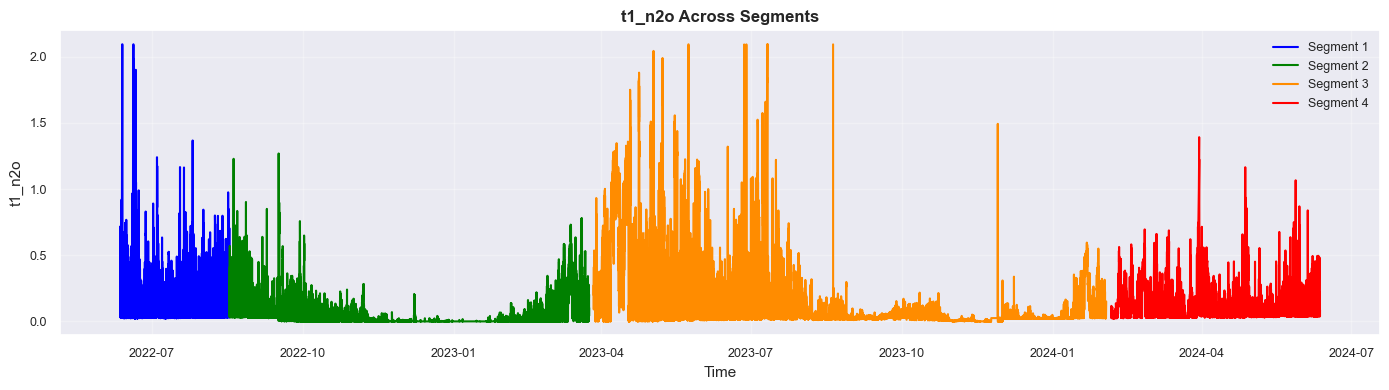

In [166]:
#Plot n2o for each segment to check for patterns 
plt.figure(figsize=(14,4))

for seg_id, seg_df in segments.items():
    plt.plot(
        seg_df.index,
        seg_df["t1_n2o"],
        label=f"Segment {seg_id}",
        color=segment_colors[seg_id]
    )

plt.title("t1_n2o Across Segments")
plt.xlabel("Time")
plt.ylabel("t1_n2o")
plt.legend()
plt.tight_layout()
plt.show()

In [163]:
def plot_segments_overlay(df_segmented, variables):

    segment_ids = sorted(df_segmented["segment_id"].unique())

    for var in variables:
        plt.figure(figsize=(14,6))

        for seg_id in segment_ids:
            seg_df = df_segmented[df_segmented["segment_id"] == seg_id]

            plt.plot(
                seg_df.index,
                seg_df[var],
                label=f"Segment {seg_id}",
                color=segment_colors[seg_id]   # ← uses dictionary
            )

        plt.title(f"{var} Comparison Across Segments")
        plt.xlabel("Time")
        plt.ylabel(var)
        plt.legend()
        plt.tight_layout()
        plt.show()

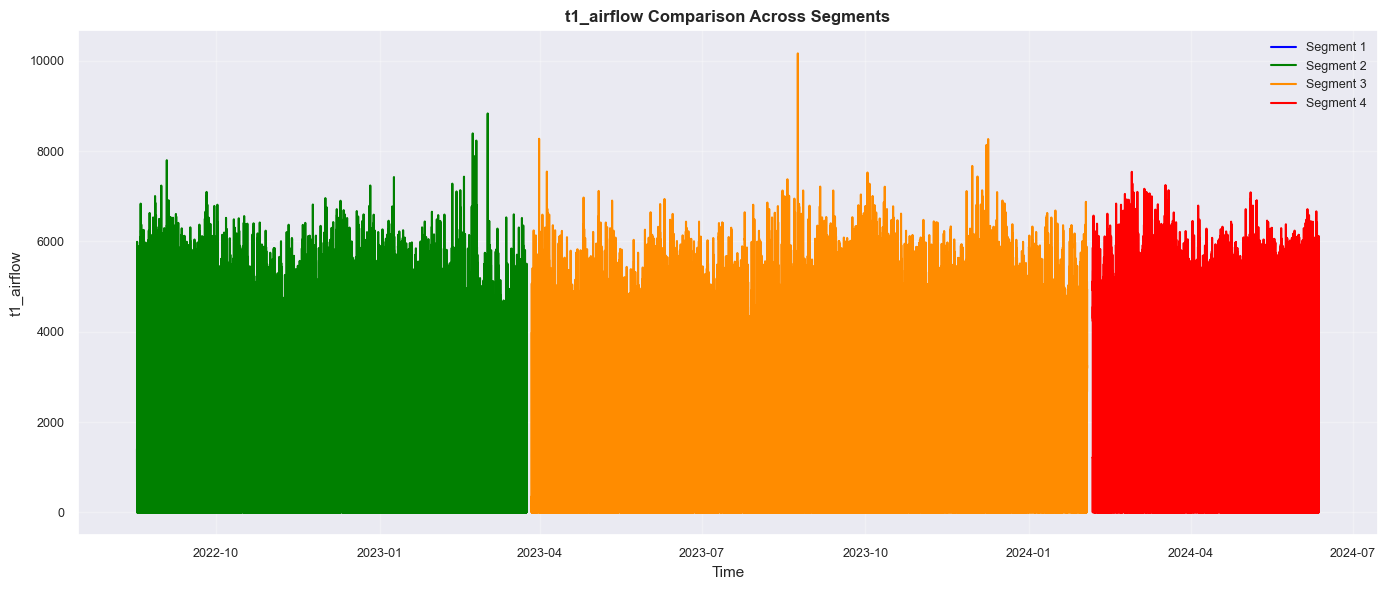

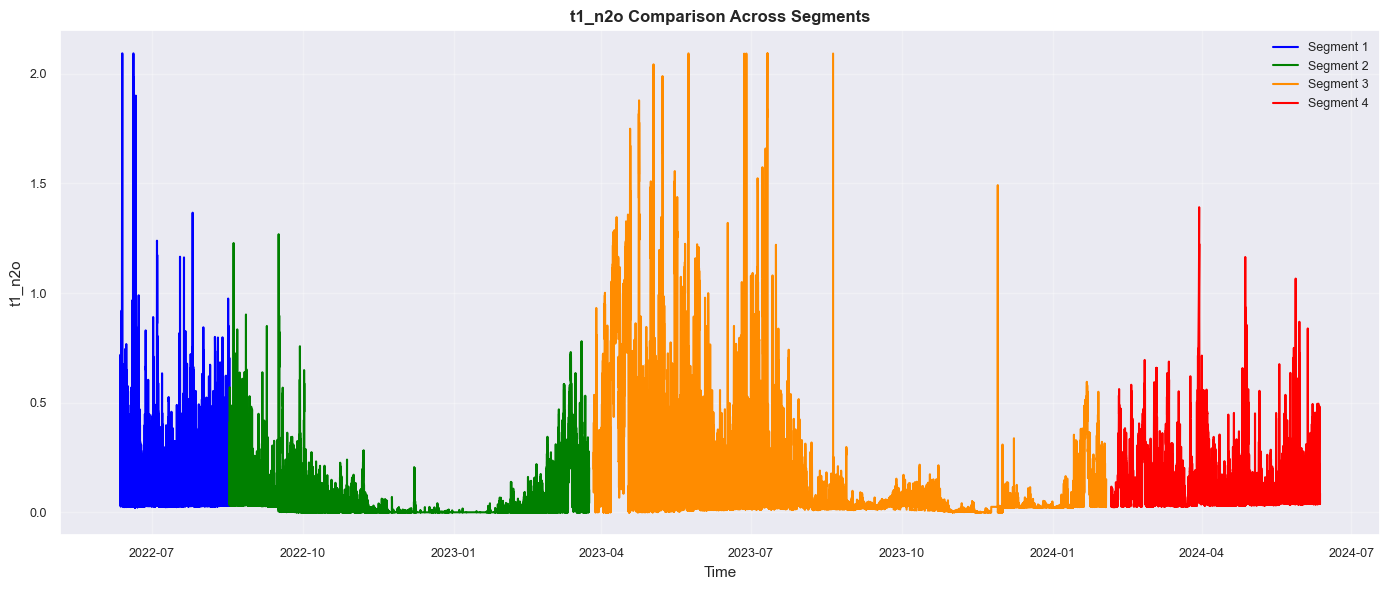

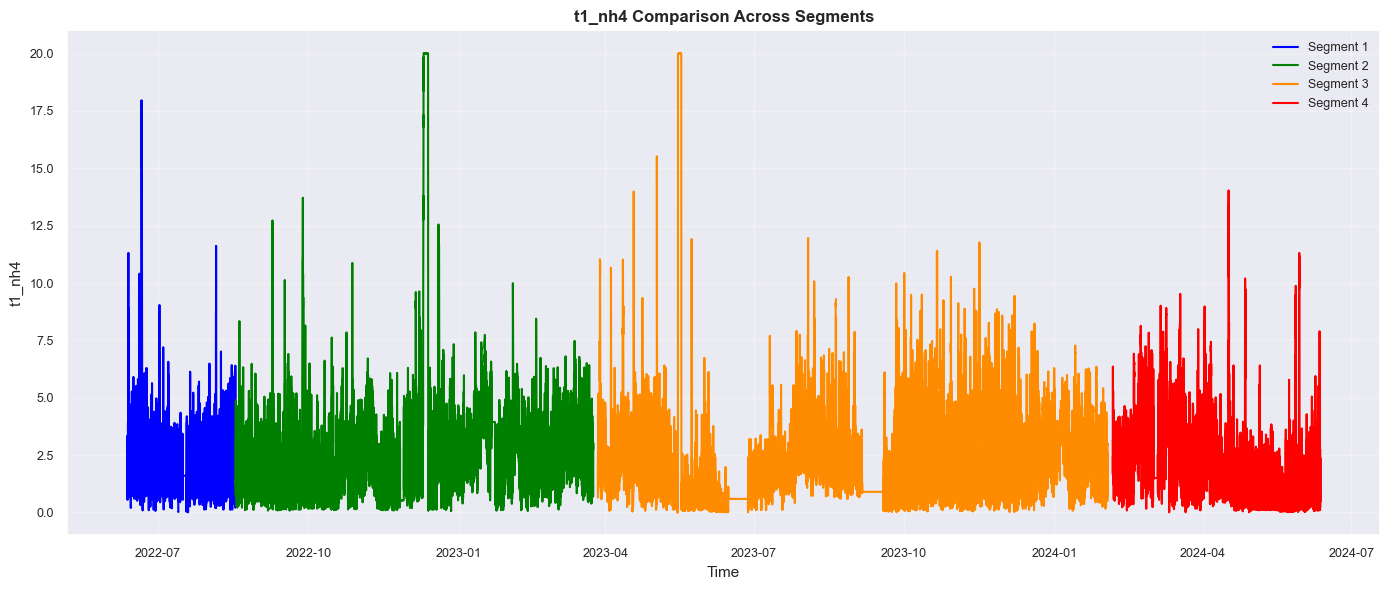

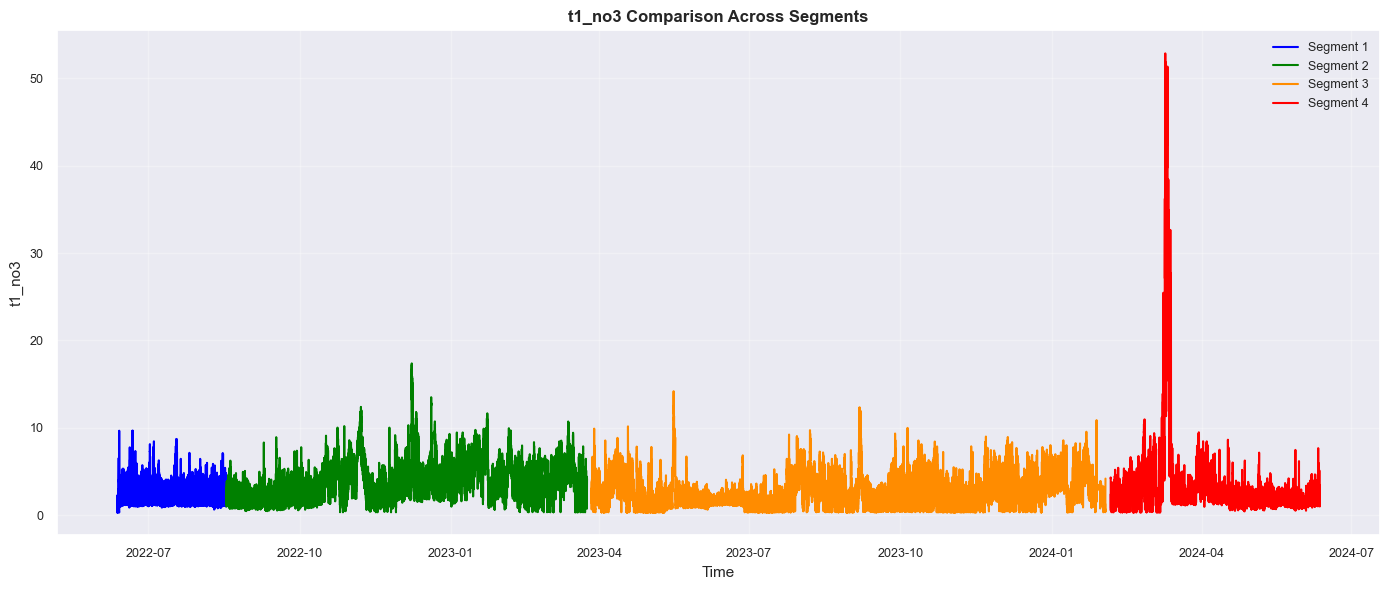

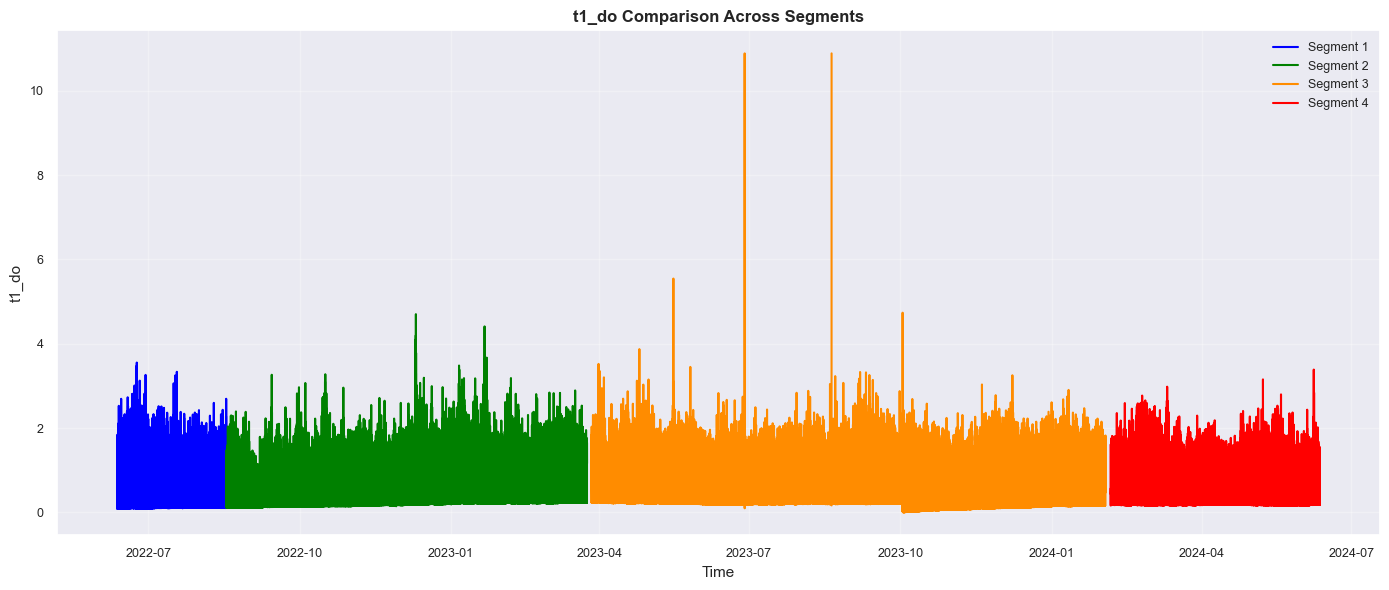

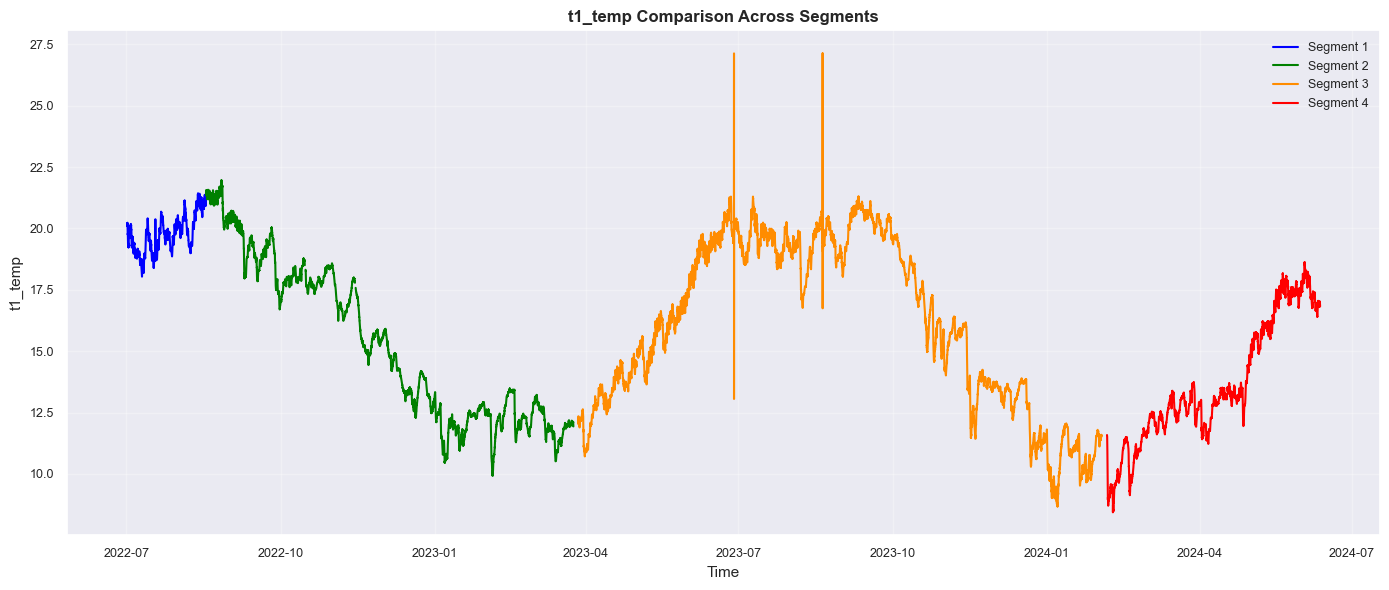

In [167]:
variables = cols_gaps
plot_segments_overlay(df_10T_segments, variables)

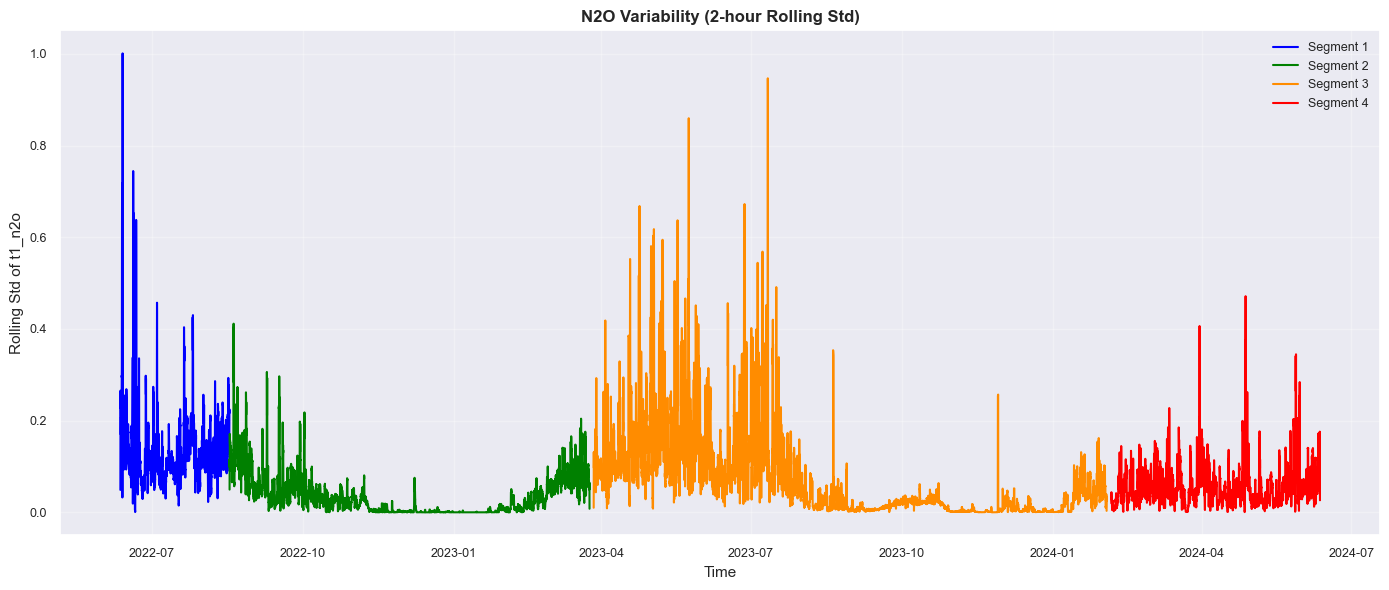

In [168]:
#Plot 2-hour rolling variability 

window = 36  # 6 hours for 10-min data

plt.figure(figsize=(14,6))

for seg_id in segment_ids:
    
    seg_df = df_10T_segments[df_10T_segments["segment_id"] == seg_id]
    
    rolling_std = seg_df["t1_n2o"].rolling(
        window=window,
        min_periods=1
    ).std()
        
    plt.plot(
        seg_df.index,
        rolling_std,
        label=f"Segment {seg_id}",
        color=segment_colors[seg_id]   # ← updated
    )

plt.title("N2O Variability (2-hour Rolling Std)")
plt.xlabel("Time")
plt.ylabel("Rolling Std of t1_n2o")
plt.legend()
plt.tight_layout()
plt.show()

In [169]:
def plot_n2o_rolling_variability(df_10T_segments):

    df_10T_segments = df_10T_segments.sort_index()
    segment_ids = sorted(df_10T_segments["segment_id"].unique())

    # For 10-min data:
    window_2h = 12   # 2 hours = 12 * 10 minutes
    window_4h = 24   # 4 hours = 24 * 10 minutes

    for seg_id in segment_ids:

        seg_df = df_10T_segments[
            df_10T_segments["segment_id"] == seg_id
        ]

        # ---------- 2-Hour Rolling Std ----------
        print(f"Segment {seg_id} - 2-Hour Rolling Std of N2O")

        rolling_std_2h = seg_df["t1_n2o"].rolling(
            window=window_2h,
            min_periods=1
        ).std()

        plt.figure(figsize=(14,5))
        plt.plot(
            seg_df.index,
            rolling_std_2h,
            color=segment_colors[seg_id]   # ← UPDATED LINE
        )
        plt.title(f"Segment {seg_id} – 2-Hour Rolling Std of N2O")
        plt.xlabel("Time")
        plt.ylabel("Rolling Std (2h)")
        plt.tight_layout()
        plt.show()

        # ---------- 4-Hour Rolling Std ----------
        print(f"Segment {seg_id} - 4-Hour Rolling Std of N2O")

        rolling_std_4h = seg_df["t1_n2o"].rolling(
            window=window_4h,
            min_periods=1
        ).std()

        plt.figure(figsize=(14,5))
        plt.plot(
            seg_df.index,
            rolling_std_4h,
            color=segment_colors[seg_id]   # ← UPDATED LINE
        )
        plt.title(f"Segment {seg_id} – 4-Hour Rolling Std of N2O")
        plt.xlabel("Time")
        plt.ylabel("Rolling Std (4h)")
        plt.tight_layout()
        plt.show()

Segment 1 - 2-Hour Rolling Std of N2O


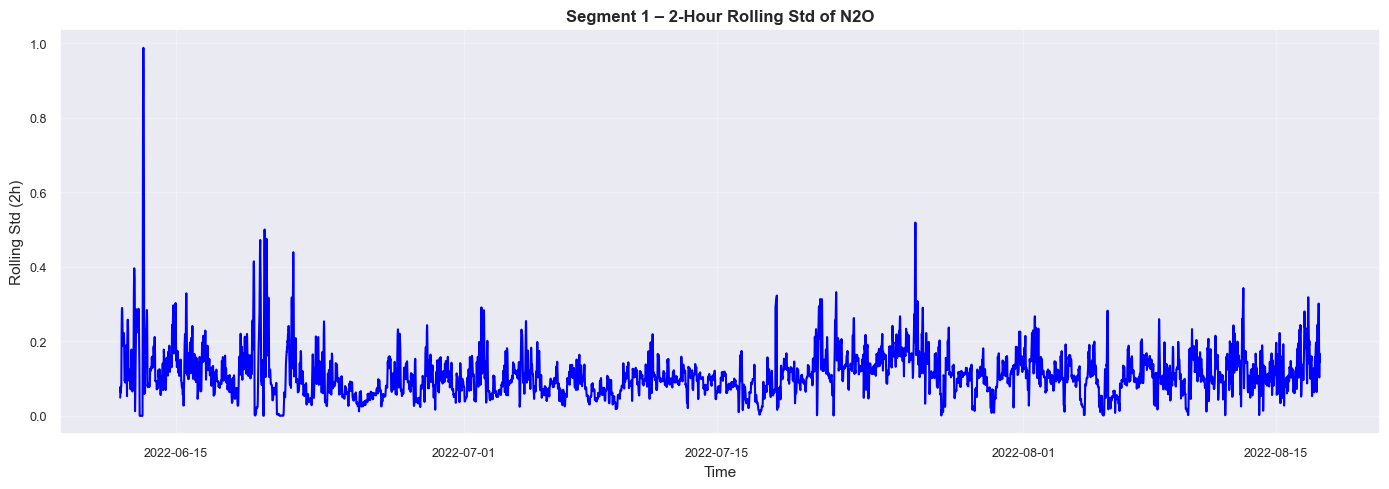

Segment 1 - 4-Hour Rolling Std of N2O


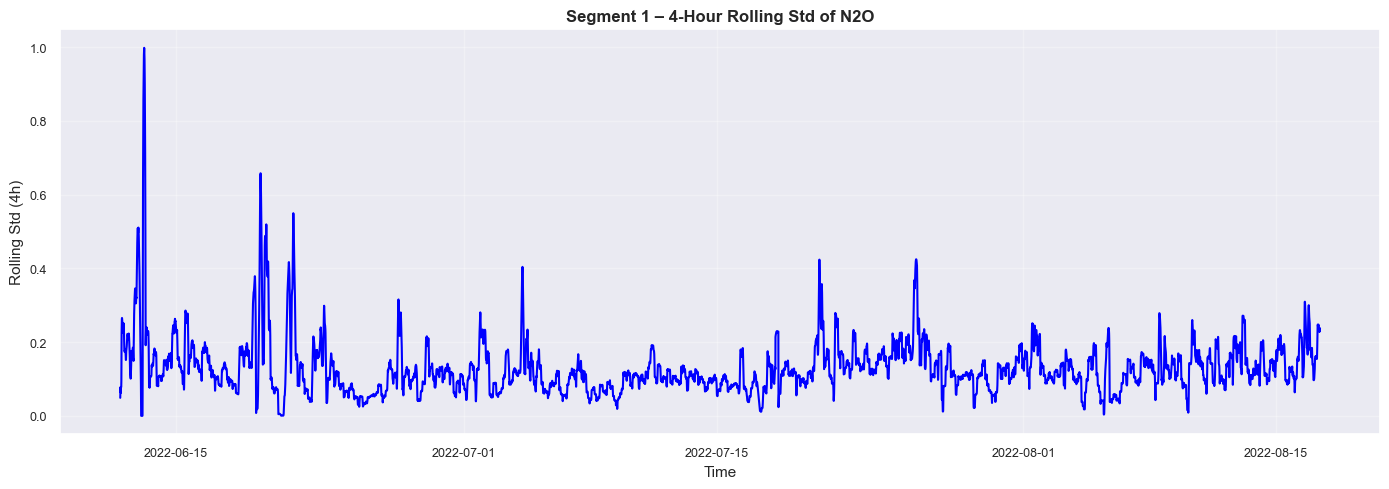

Segment 2 - 2-Hour Rolling Std of N2O


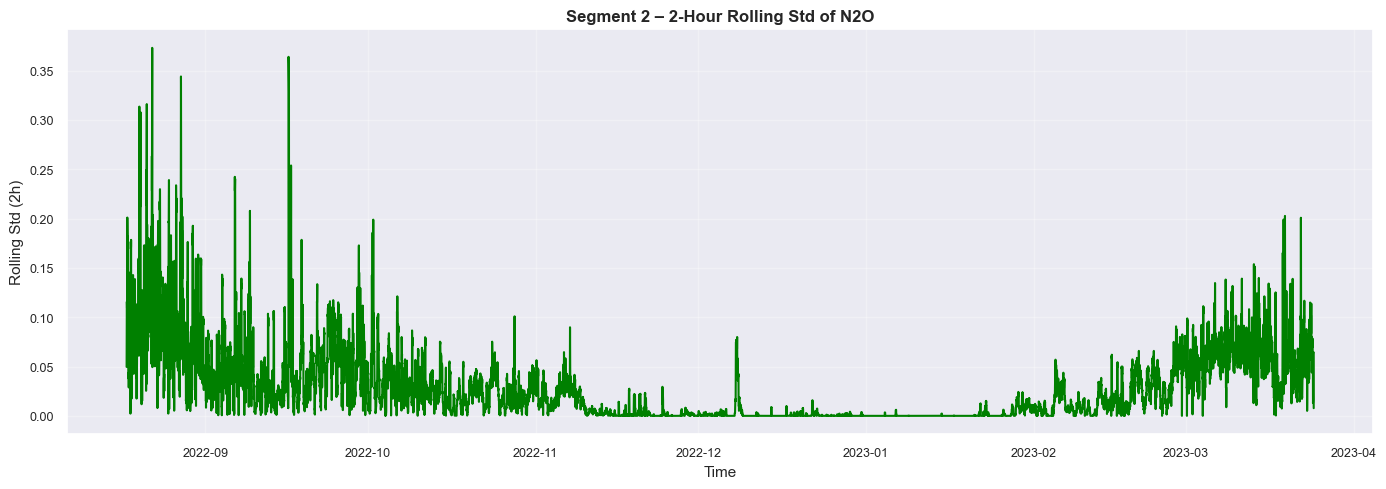

Segment 2 - 4-Hour Rolling Std of N2O


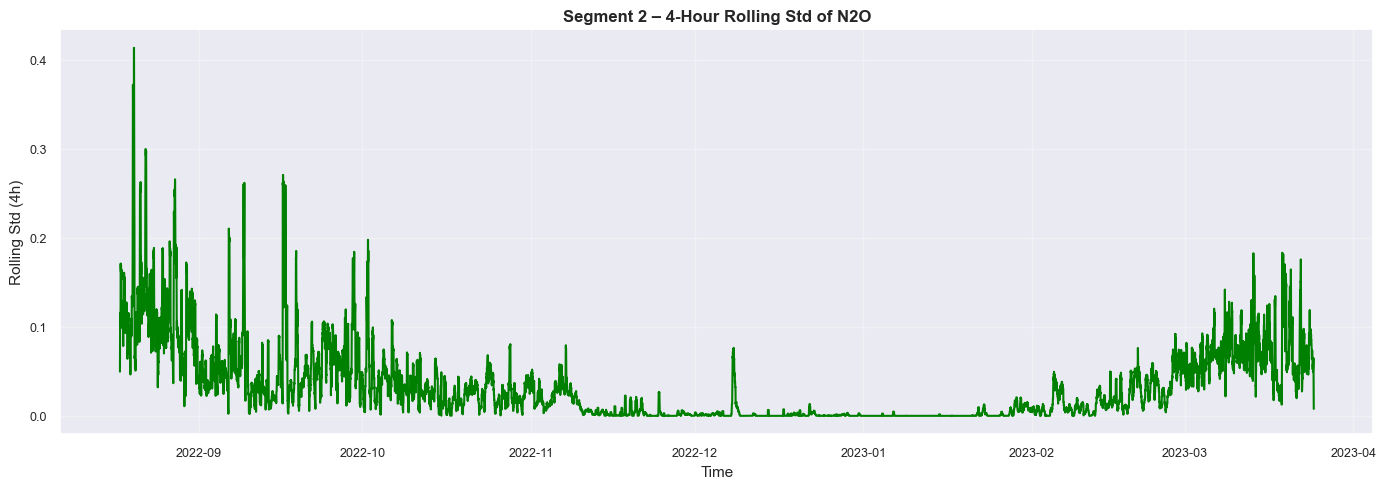

Segment 3 - 2-Hour Rolling Std of N2O


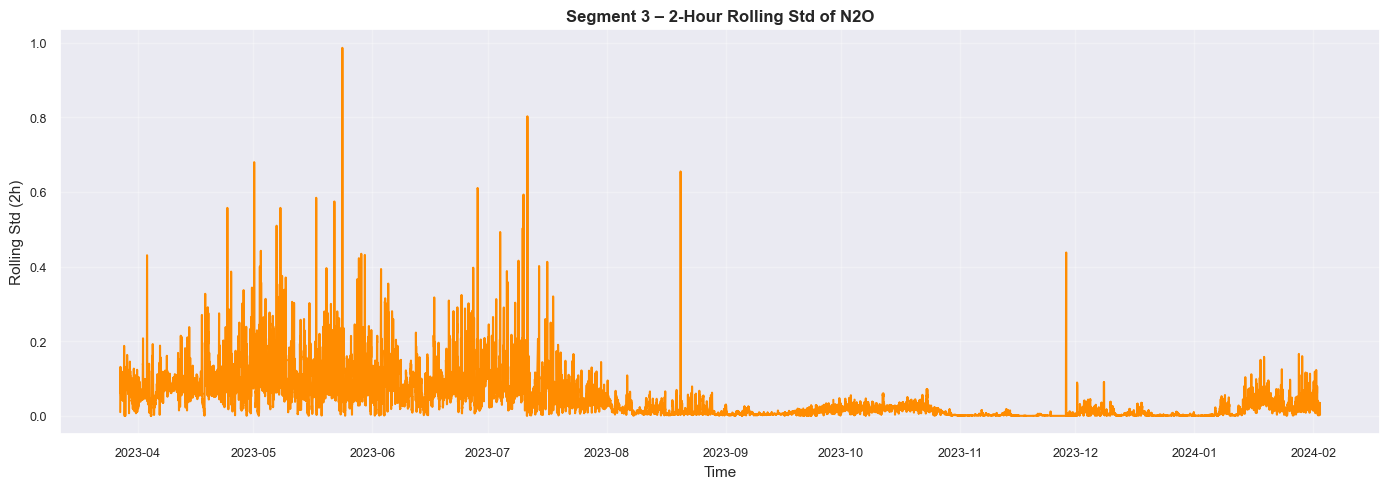

Segment 3 - 4-Hour Rolling Std of N2O


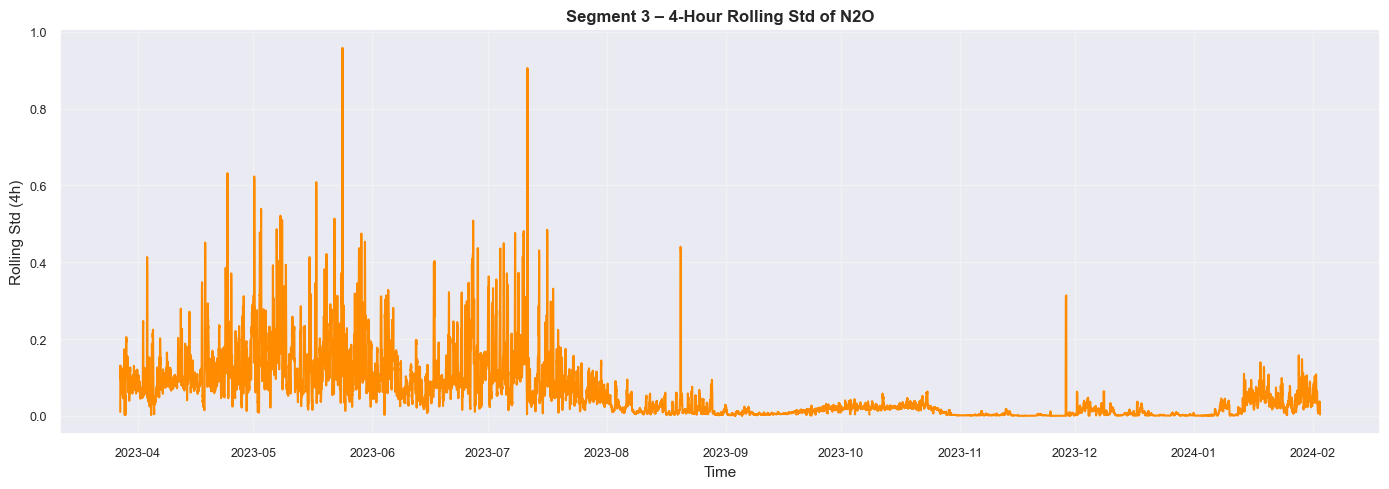

Segment 4 - 2-Hour Rolling Std of N2O


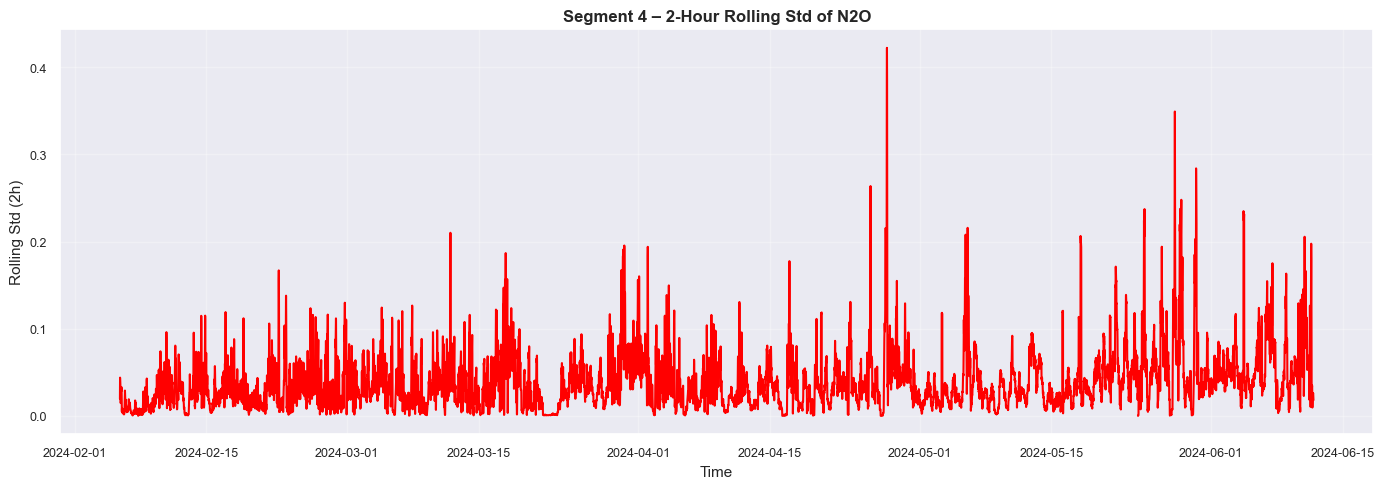

Segment 4 - 4-Hour Rolling Std of N2O


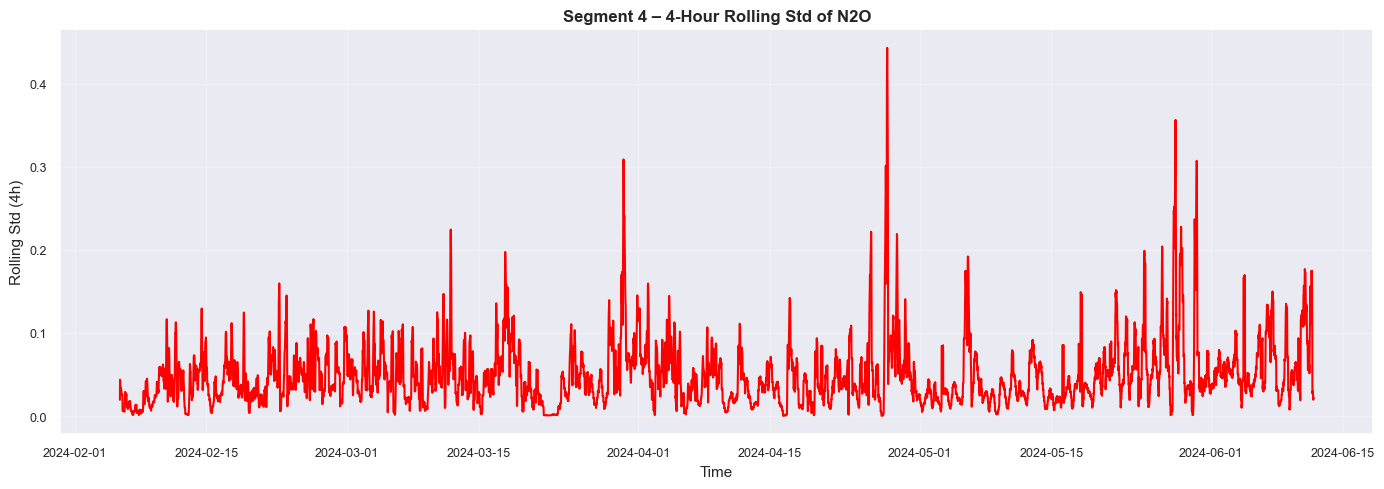

In [170]:
plot_n2o_rolling_variability(df_10T_segments)

In [143]:
def n2o_variability_summary(df_segmented):
    
    summary = []
    
    for seg_id in sorted(df_segmented["segment_id"].unique()):
        seg_df = df_segmented[df_segmented["segment_id"] == seg_id]
        
        summary.append({
            "segment_id": seg_id,
            "duration_days": ((seg_df.index.max() - seg_df.index.min()).total_seconds() / 86400),
            "mean_n2o": seg_df["t1_n2o"].mean(),
            "std_n2o": seg_df["t1_n2o"].std(),
            "p95_n2o": seg_df["t1_n2o"].quantile(0.95),
            "p99_n2o": seg_df["t1_n2o"].quantile(0.99)
        })
    
    summary_df = pd.DataFrame(summary).sort_values("std_n2o", ascending=False)
    
    return summary_df

In [144]:
n2o_variability_summary(df_10T_segments)

,segment_id,duration_days,mean_n2o,std_n2o,p95_n2o,p99_n2o
2,3,315.451389,0.168452,0.283679,0.840081,1.263035
0,1,66.534722,0.205268,0.260948,0.611458,1.533056
3,4,127.125000,0.130777,0.147350,0.456597,0.660877
1,2,221.861111,0.048129,0.103636,0.251134,0.536898
